<a href="https://colab.research.google.com/github/NoeliaOrsini/synthdata-data-analytics/blob/main/synthdata_data_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 1
## 1.- Crear un documento en Google Colaboratory y cargar los sets de datos como DataFrames.

En este primer paso, se configura el entorno de trabajo en Google Colab utilizando la librería Pandas para el análisis y manipulación de las estructuras de datos.

A diferencia del enfoque inicial con archivos locales, se optimizó el flujo de trabajo consumiendo los datasets directamente desde URLs públicas de Google Sheets (pub?output=csv). Esta metodología elimina la necesidad de subir manualmente los archivos físicos en cada sesión de Colab, garantizando la disponibilidad inmediata y centralizada de la información mediante la función pd.read_csv() para su posterior diagnóstico (.info()).

In [ ]:
import pandas as pd

# 1. Carga de datasets desde URLs públicas
df_ventas = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQpQMtDU1Hqh5HjVtQa4xhAVrhTYVofxNlYEFRB3s23tpjA2ojTIar0G-8U2hyr5QwwULz5pkIFQ8zk/pub?output=csv")
df_marketing = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTw4WYGxMh_8v4ZH-4ndoN8VglmUwM67xFJspgLTIa5ELNNZag2eFA6ycmturBLMkQbj3iovcXFUeIV/pub?output=csv")
df_clientes = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQ6u4NL86Gu5OMicA48y8aHyTTD5Esl0Sbe3FFNfp837ZC0RfVjlMGpz4hiU7leHOt8zGvhUsSDu3Jo/pub?output=csv")

# 2. Diagnóstico de estructuras y tipos de datos
print("///////////////// INFO VENTAS /////////////////")
df_ventas.info()

print("\n///////////////// INFO CLIENTES /////////////////")
df_clientes.info()

print("\n///////////////// INFO MARKETING /////////////////")
df_marketing.info()

# 3. Visualización de encabezados y consistencia de datos
print("\n--- Vista previa: Ventas ---")
display(df_ventas.head(3))

print("\n--- Vista previa: Clientes ---")
display(df_clientes.head(3))

print("\n--- Vista previa: Marketing ---")
display(df_marketing.head(3))

///////////////// INFO VENTAS /////////////////
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   object 
 2   precio       3033 non-null   object 
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   object 
 5   categoria    3035 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 142.4+ KB

///////////////// INFO CLIENTES /////////////////
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 567 entries, 0 to 566
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id_cliente  567 non-null    int64  
 1   nombre      567 non-null    object 
 2   edad        567 non-null    int64  
 3   ciudad      567 non-null    object 
 4   ingresos    567 non-null    float64
dtyp

,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos



--- Vista previa: Clientes ---


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85



--- Vista previa: Marketing ---


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024


##2.- Realizar un script básico que calcule las ventas mensuales utilizando variables y operadores.

Se desarrolló una función reutilizable en Python para simular el cálculo de ventas sin interactuar con los DataFrames. El script utiliza un bucle for y un acumulador básico para sumar una lista de valores numéricos ficticios, permitiendo obtener el total de ventas de un período determinado, en este caso enero y febrero 2026.

In [ ]:
# 1. Definición de la función
def calcular_ventas_mensuales(ventas_mensuales = []):
    venta_total = 0
    for venta in ventas_mensuales:
        venta_total = venta + venta_total
    return venta_total

# 2. Prueba del uso de la función con distintos meses
print("--- Ventas totales enero y febrero 2026 ---")

enero = [10, 110, 23, 55]
print(f"Total Ventas Enero: ${calcular_ventas_mensuales(enero)}")

febrero = [45, 60, 120]
print(f"Total Ventas Febrero: ${calcular_ventas_mensuales(febrero)}")

--- Ventas totales enero y febrero 2026 ---
Total Ventas Enero: $198
Total Ventas Febrero: $225


##3.- Estructuras de Datos: Desarrollar un programa que almacene los datos de ventas (producto, precio, cantidad). Decidir si conviene utilizar diccionarios o listas.

En este paso se crea un diccionario llamado DB que contiene tres listas vacías: una para los nombres de los productos, otra para los precios y otra para las cantidades. Esta estructura permite separar los datos en columnas independientes de forma organizada.

Mediante un bucle while y la función input(), se simula una carga de datos donde el usuario puede ingresar los valores de forma manual. Cada dato ingresado se agrega directamente a su lista correspondiente usando el método .append().

Para finalizar, este diccionario de listas se transforma en un DataFrame de Pandas (pd.DataFrame(DB)).


In [ ]:
# --- PUNTO 3: CARGA DE DATOS CON WHILE ---

# Creo el diccionario vacío con las listas para armar las columnas
DB = {
    "Producto": [],
    "Precio": [],
    "Cantidad": []
}

print("--- Inicio de la carga de productos ---")

# Bucle para cargar los datos de forma manual
while True:
    nombre = input("Ingrese el nombre del producto: ")
    precio = float(input("Ingrese el precio unitario: "))
    cantidad = int(input("Ingrese la cantidad de unidades: "))

    # Agrego cada dato a su lista correspondiente
    DB["Producto"].append(nombre)
    DB["Precio"].append(precio)
    DB["Cantidad"].append(cantidad)

    # Opción para salir del bucle
    seleccion = input("Toque 'x' para salir o cualquier tecla para continuar: ")
    if seleccion.lower() == "x":
        break

# Convierto el diccionario terminado en un DataFrame de Pandas
print("\n--- Vista previa del DataFrame ---")
inventario_ventas = pd.DataFrame(DB)
display(inventario_ventas)

--- Inicio de la carga de productos ---
Ingrese el nombre del producto: Lámpara
Ingrese el precio unitario: 15000
Ingrese la cantidad de unidades: 30
Toque 'x' para salir o cualquier tecla para continuar: z
Ingrese el nombre del producto: Cuadro decorativo
Ingrese el precio unitario: 12000
Ingrese la cantidad de unidades: 8
Toque 'x' para salir o cualquier tecla para continuar: z
Ingrese el nombre del producto: Auriculares
Ingrese el precio unitario: 8000
Ingrese la cantidad de unidades: 15
Toque 'x' para salir o cualquier tecla para continuar: x

--- Vista previa del DataFrame ---


,Producto,Precio,Cantidad
0,Lámpara,15000.0,30
1,Cuadro decorativo,12000.0,8
2,Auriculares,8000.0,15


##4.- Introducción a Pandas: realizar un análisis exploratorio inicial de los DataFrames.
Luego del mapeo general que realicé con `info()` en la etapa de carga (punto 1), procedo ahora a una exploración más exhaustiva de los tres DataFrames para validar la integridad de mi información.

En esta instancia, no solo verifico las dimensiones con `len()`, sino que utilizo los métodos `.head()` y `.tail()` para observar la consistencia del contenido tanto al inicio como al final de las tablas.

Asimismo, reviso nuevamente los tipos de datos con `.dtypes`. Esta propiedad nos devuelve el tipo de dato de cada columna del DataFrame (por ejemplo, `int64` para números enteros, `float64` para decimales y `object` para cadenas de texto o strings).

In [ ]:
# --- EXPLORACIÓN DEL DATAFRAME DE VENTAS ---
print("||||||||||||||| MI ANÁLISIS DE VENTAS |||||||||||||||")
print(f"\nTotal de registros: {len(df_ventas)}")
print("\nPrimeros registros (Control de cabeceras):")
display(df_ventas.head())

print("\nÚltimos registros (Control de cierre):")
display(df_ventas.tail())

print("\nVerificación de tipos de datos:")
print(df_ventas.dtypes)
print("\n\n")

# --- EXPLORACIÓN DEL DATAFRAME DE CLIENTES ---
print("||||||||||||||| MI ANÁLISIS DE CLIENTES |||||||||||||||")
print(f"\nTotal de registros: {len(df_clientes)}")
print("\nPrimeros registros:")
display(df_clientes.head())

print("\nÚltimos registros (Control de cierre):")
display(df_clientes.tail())

print("\nTipos de datos por columna:")
print(df_clientes.dtypes)
print("\n\n")

# --- EXPLORACIÓN DEL DATAFRAME DE MARKETING ---
print("||||||||||||||| MI ANÁLISIS DE MARKETING |||||||||||||||")
print(f"\nTotal de registros: {len(df_marketing)}")
print("\nPrimeros registros:")
display(df_marketing.head())
print("\nÚltimos registros (Control de cierre):")
display(df_marketing.tail())
print("\nTipos de datos por columna:")
print(df_marketing.dtypes)
print("\n\n")

||||||||||||||| MI ANÁLISIS DE VENTAS |||||||||||||||

Total de registros: 3035

Primeros registros (Control de cabeceras):


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro decorativo,$69.94,5.0,02/01/2024,Decoración
1,811,Lámpara de mesa,$105.10,5.0,02/01/2024,Decoración
2,1156,Secadora,$97.96,3.0,02/01/2024,Electrodomésticos
3,1372,Heladera,$114.35,8.0,02/01/2024,Electrodomésticos
4,1546,Secadora,$106.21,4.0,02/01/2024,Electrodomésticos



Últimos registros (Control de cierre):


,id_venta,producto,precio,cantidad,fecha_venta,categoria
3030,1837,Horno eléctrico,$104.12,9.0,30/12/2024,Electrodomésticos
3031,2276,Laptop,$85.27,9.0,30/12/2024,Electrónica
3032,2696,Laptop,$107.81,4.0,30/12/2024,Electrónica
3033,2913,Smartphone,$99.85,7.0,30/12/2024,Electrónica
3034,2930,Consola de videojuegos,$55.47,6.0,30/12/2024,Electrónica



Verificación de tipos de datos:
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object



||||||||||||||| MI ANÁLISIS DE CLIENTES |||||||||||||||

Total de registros: 567

Primeros registros:


...


Tipos de datos por columna:
id_cliente      int64
nombre         object
edad            int64
ciudad         object
ingresos      float64
dtype: object



||||||||||||||| MI ANÁLISIS DE MARKETING |||||||||||||||

Total de registros: 90

Primeros registros:


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno de pared,TV,4.81,20/03/2024,03/05/2024
1,12,Tablet,RRSS,3.40,26/03/2024,13/05/2024
2,32,Lámpara de mesa,Email,5.54,28/03/2024,20/04/2024
3,21,Smartphone,RRSS,6.37,29/03/2024,16/05/2024
4,58,Alfombra,Email,4.25,31/03/2024,05/05/2024



Últimos registros (Control de cierre):


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
85,70,Aspiradora,TV,3.06,13/12/2024,29/12/2024
86,89,Televisor,TV,4.98,13/12/2024,8/2/2025
87,68,Rincón de plantas,TV,5.81,17/12/2024,14/2/2025
88,33,Secadora,Email,3.80,20/12/2024,7/1/2025
89,11,Freidora eléctrica,RRSS,5.27,29/12/2024,21/1/2025



Tipos de datos por columna:
id_campanha       int64
producto         object
canal            object
costo           float64
fecha_inicio     object
fecha_fin        object
dtype: object





##5.- Calidad de Datos: Identificar valores nulos y duplicados en los conjuntos de datos.

En esta fase final de la Etapa 1, realicé una evaluación de la integridad de los datasets de Ventas, Clientes y Marketing. Mi objetivo principal fue identificar valores faltantes (nulos) y registros repetidos (duplicados) para documentar el estado inicial de la información, antes de proceder a cualquier fase de limpieza profunda.

In [ ]:
# --- ANALISIS DE CALIDAD DE LOS DATOS ---

print("||||||||||||||| NULOS Y DUPLICADOS EN VENTAS |||||||||||||||")
print(f"\nValores nulos por columna:\n{df_ventas.isnull().sum()}")
# Filas nulas
filas_nulas_ventas = df_ventas[df_ventas.isnull().any(axis=1)]
print(f"\nFilas con valores nulos:\n{filas_nulas_ventas}")
print(f"\nFilas duplicadas totales: {df_ventas.duplicated().sum()}")
# Duplicados ordenados por ID
ventas_duplicadas = df_ventas[df_ventas.duplicated()].sort_values(by="id_venta")
print(f"\nRegistros duplicados detectados:\n{ventas_duplicadas}")
print("\n\n")


print("||||||||||||||| NULOS Y DUPLICADOS EN CLIENTES |||||||||||||||")
print(f"\nValores nulos por columna:\n{df_clientes.isnull().sum()}")
# Filas nulas
filas_nulas_clientes = df_clientes[df_clientes.isnull().any(axis=1)]
print(f"\nFilas con valores nulos:\n{filas_nulas_clientes}")
print(f"\nFilas duplicadas totales: {df_clientes.duplicated().sum()}")
# Duplicados ordenados por su ID correspondiente
clientes_duplicados = df_clientes[df_clientes.duplicated()].sort_values(by="id_cliente")
print(f"\nRegistros duplicados detectados:\n{clientes_duplicados}")
print("\n\n")


print("||||||||||||||| NULOS Y DUPLICADOS EN MARKETING |||||||||||||||")
print(f"\nValores nulos por columna:\n{df_marketing.isnull().sum()}")
# Filas nulas
filas_nulas_marketing = df_marketing[df_marketing.isnull().any(axis=1)]
print(f"\nFilas con valores nulos:\n{filas_nulas_marketing}")
print(f"\nFilas duplicadas totales: {df_marketing.duplicated().sum()}")
# Duplicados ordenados por su ID: id_campanha
marketing_duplicados = df_marketing[df_marketing.duplicated()].sort_values(by="id_campanha")
print(f"\nRegistros duplicados detectados:\n{marketing_duplicados}")
print("\n\n")

||||||||||||||| NULOS Y DUPLICADOS EN VENTAS |||||||||||||||

Valores nulos por columna:
id_venta       0
producto       0
precio         2
cantidad       2
fecha_venta    0
categoria      0
dtype: int64

Filas con valores nulos:
     id_venta               producto precio  cantidad fecha_venta    categoria
136       627  Elementos de cerámica    NaN       NaN  17/01/2024   Decoración
139      2171    Parlantes Bluetooth    NaN       NaN  17/01/2024  Electrónica

Filas duplicadas totales: 35

Registros duplicados detectados:
     id_venta                producto   precio  cantidad fecha_venta  \
826        56                Cortinas   $66.24       5.0  05/04/2024   
844       145                Alfombra   $41.72       8.0  06/04/2024   
884       204       Jarrón decorativo   $94.75       1.0  08/04/2024   
867       213       Espejo decorativo   $40.76       8.0  07/04/2024   
845       300         Adorno de pared   $67.75       9.0  06/04/2024   
868       345                Alfombra

## Análisis Preliminar - Etapa 1:

Tras completar el análisis exploratorio y la auditoría de calidad de los datos, se determinó el estado inicial de los tres conjuntos de información. Los hallazgos principales son:

* **Dataset de Ventas:** Se identificaron 35 registros duplicados y 2 valores nulos en columnas fundamentales como precio y cantidad. Estos nulos impactan directamente en cualquier cálculo derivado (como un potencial total de venta), generando registros incompletos que representan el punto más crítico a sanear.

* **Dataset de Clientes:** Presenta una integridad óptima, registrando cero valores nulos y cero filas duplicadas. Esto lo posiciona como una base de datos limpia y sólida para futuros cruces de información.

* **Dataset de Marketing:** No presenta nulos ni duplicados en esta lectura inicial. Sin embargo, mediante la revisión de tipos de datos, se observa la necesidad de una futura estandarización de formatos en los canales de comunicación y en las columnas de fechas para asegurar su correcta explotación analítica.

**Nota:** Estos hallazgos documentados constituyen el diagnóstico inicial y la base del plan de acción para la Etapa 2. En la siguiente fase se ejecutará la limpieza profunda, la eliminación de redundancias y la unificación de criterios estructurales como fechas estas figuran como object en ventas y en marketing, nombres, ciudades, cambiar precio que está como string, sacar signo pesos en el dataset ventas, entre otros.

# Actividad 2: Limpieza y Transformación de Datos

## 1.- Limpieza de Datos: Limpiar el conjunto de datos eliminando duplicados y caracteres no deseados. Documentar el proceso y los resultados.

Tras el análisis exploratorio de la Etapa 1, se ejecutaron las acciones de limpieza estructuradas en dos bloques secuenciales de código para garantizar la eficiencia, prolijidad y la integridad de los datos antes de proceder a cualquier fase de cálculo:

In [ ]:
# ==============================================================================
# BLOQUE 1: SANEAMIENTO DE REGISTROS Y LIMPIEZA DE CARACTERES ESPECIALES
# ==============================================================================

print("||||||||||||||| INICIANDO BLOQUE 1: LIMPIEZA DE REGISTROS |||||||||||||||\n")

# 1. Eliminación de filas duplicadas detectadas y guardado en nueva variable limpia
df_ventas_limpio = df_ventas.drop_duplicates()

# 2. Eliminación de registros con valores nulos en columnas precio y cantidad sobre el dataset limpio
df_ventas_limpio = df_ventas_limpio.dropna(subset=['precio', 'cantidad'])

# 3. Limpieza del signo '$' y conversión de la columna precio a tipo numérico (float)
df_ventas_limpio["precio"] = df_ventas_limpio["precio"].str.replace("$", "", regex=False).astype(float)

print("✓ Duplicados y valores nulos eliminados con éxito.")
print("✓ Columna 'precio' convertida a número decimal (float).")

||||||||||||||| INICIANDO BLOQUE 1: LIMPIEZA DE REGISTROS |||||||||||||||

✓ Duplicados y valores nulos eliminados con éxito.
✓ Columna 'precio' convertida a número decimal (float).


#Verificación Final:
Con los datos ya saneados, procedo a realizar una última verificación. En esta instancia, confirmo que no existan remanentes de duplicados o nulos y verifico que los tipos de datos sean los correctos para operar.

 Se incluye una vista previa de los tres datasets para constatar la correcta normalización de los textos.

In [ ]:
# ==============================================================================
# BLOQUE 2: AJUSTE DE FORMATOS Y VERIFICACIÓN POST-LIMPIEZA
# ==============================================================================

print("||||||||||||||| AJUSTES FORMATOS Y VERIFICACIÓN |||||||||||||||\n")

# --- Creación de copias limpias para Clientes y Marketing ---
# (df_ventas_limpio ya lo cree y sanee en el Bloque 1)
df_clientes_limpio = df_clientes.copy()
df_marketing_limpio = df_marketing.copy()


# 1. Conversión de fechas de Object a Datetime (Día/Mes/Año) en las tablas limpias
df_ventas_limpio["fecha_venta"] = pd.to_datetime(df_ventas_limpio["fecha_venta"], format="%d/%m/%Y")
df_marketing_limpio["fecha_inicio"] = pd.to_datetime(df_marketing_limpio["fecha_inicio"], format="%d/%m/%Y")
df_marketing_limpio["fecha_fin"] = pd.to_datetime(df_marketing_limpio["fecha_fin"], format="%d/%m/%Y")


# 2. Estandarización de textos (Formato Título: Mayúscula Inicial) en las tablas limpias
df_ventas_limpio['producto'] = df_ventas_limpio['producto'].str.title()
df_ventas_limpio['categoria'] = df_ventas_limpio['categoria'].str.title()

df_clientes_limpio['nombre'] = df_clientes_limpio['nombre'].str.title()
df_clientes_limpio['ciudad'] = df_clientes_limpio['ciudad'].str.title()

df_marketing_limpio['producto'] = df_marketing_limpio['producto'].str.title()
df_marketing_limpio['canal'] = df_marketing_limpio['canal'].str.title()

print("✓ Formato de fechas y textos normalizados con éxito.\n")


# --- 3. REPORTE DE CALIDAD POST-LIMPIEZA ---
print("==========================================================")
print("--- REPORTE DE CALIDAD POST-LIMPIEZA ---")
print("==========================================================")
print(f"¿Quedan registros duplicados en Ventas?: {df_ventas_limpio.duplicated().sum()}")
print(f"¿Hay valores nulos en Precio de Ventas?: {df_ventas_limpio['precio'].isnull().sum()}")
print(f"¿Hay valores nulos en Cantidad de Ventas?: {df_ventas_limpio['cantidad'].isnull().sum()}")
print(f"Tipo de dato final de 'precio': {df_ventas_limpio['precio'].dtype}")
print(f"Tipo de dato final de 'fecha_venta': {df_ventas_limpio['fecha_venta'].dtype}")
print(f"Tipo de dato final de 'fecha_inicio': {df_marketing_limpio['fecha_inicio'].dtype}")
print(f"Tipo de dato final de 'fecha_fin': {df_marketing_limpio['fecha_fin'].dtype}\n")


# --- 4. VISTA PREVIA DE LOS 3 DATASETS LIMPIOS ---
print("--- VISTA PREVIA: VENTAS (Saneado) ---")
display(df_ventas_limpio.head(3))

print("\n--- VISTA PREVIA: CLIENTES (Saneado) ---")
display(df_clientes_limpio.head(3))

print("\n--- VISTA PREVIA: MARKETING (Saneado) ---")
display(df_marketing_limpio.head(3))

||||||||||||||| AJUSTES FORMATOS Y VERIFICACIÓN |||||||||||||||

✓ Formato de fechas y textos normalizados con éxito.

--- REPORTE DE CALIDAD POST-LIMPIEZA ---
¿Quedan registros duplicados en Ventas?: 0
¿Hay valores nulos en Precio de Ventas?: 0
¿Hay valores nulos en Cantidad de Ventas?: 0
Tipo de dato final de 'precio': float64
Tipo de dato final de 'fecha_venta': datetime64[ns]
Tipo de dato final de 'fecha_inicio': datetime64[ns]
Tipo de dato final de 'fecha_fin': datetime64[ns]

--- VISTA PREVIA: VENTAS (Saneado) ---


,id_venta,producto,precio,cantidad,fecha_venta,categoria
0,792,Cuadro Decorativo,69.94,5.0,2024-01-02,Decoración
1,811,Lámpara De Mesa,105.10,5.0,2024-01-02,Decoración
2,1156,Secadora,97.96,3.0,2024-01-02,Electrodomésticos



--- VISTA PREVIA: CLIENTES (Saneado) ---


,id_cliente,nombre,edad,ciudad,ingresos
0,1,Aloysia Screase,44,Mar Del Plata,42294.68
1,2,Kristina Scaplehorn,25,Posadas,24735.04
2,3,Filip Castagne,50,Resistencia,35744.85



--- VISTA PREVIA: MARKETING (Saneado) ---


,id_campanha,producto,canal,costo,fecha_inicio,fecha_fin
0,74,Adorno De Pared,Tv,4.81,2024-03-20,2024-05-03
1,12,Tablet,Rrss,3.40,2024-03-26,2024-05-13
2,32,Lámpara De Mesa,Email,5.54,2024-03-28,2024-04-20


### Justificación Técnica del Proceso y Resultados Obtenidos:
Al evaluar el impacto de los cambios reflejados en el reporte post-limpieza y las vistas previas, se detallan los siguientes fundamentos metodológicos:

* **Tratamiento de Duplicados y Nulos:** Se eliminaron las 35 filas duplicadas y los 2 registros nulos en precio y cantidad dentro de Ventas. Se optó por la remoción directa en lugar de la imputación por promedios debido a que el volumen de errores es marginal frente al tamaño total del dataset. De esta forma, resguardamos la fidelidad de los datos financieros reales sin introducir sesgos artificiales.
* **Transformación de Precios:** La remoción del símbolo `$` y la conversión a tipo numérico decimal (`float`) es el paso clave que habilita al cuaderno para operar matemáticamente con la columna, permitiendo realizar cálculos de facturación e ingresos reales más adelante.
* **Normalización de Fechas:** Se unificó la alineación temporal aplicando una conversión a formato `datetime` mediante una máscara explícita de Día/Mes/Año (`format="%d/%m/%Y"`). Esto soluciona las inconsistencias de los archivos de origen, previene la inversión accidental entre días y meses por parte de Pandas, y garantiza un orden cronológico preciso para futuros análisis de temporalidad.
* **Estandarización y Estética de Texto:** Para evitar la duplicidad de categorías por inconsistencias en la carga manual (por ejemplo, evitar que el sistema interprete "RESISTENCIA" y "Resistencia" como dos ciudades distintas), se normalizaron los campos de texto al formato de Mayúscula Inicial (Título) en los tres datasets. Esta acción no solo acompaña la prolijidad visual del reporte final, sino que asegura que cada entidad sea contabilizada de forma única y exacta.

###2- Transformación de Datos: Aplicar filtros y transformaciones para crear una tabla de ventas que muestre solo los productos con alto rendimiento.

**Evolución del criterio y justificación:**
En la instancia de preentrega, antes de aplicar un filtro arbitrario, realicé una investigación estadística exploratoria agrupando el dataset por producto y analizando las métricas de tendencia central (mínimo, máximo y media) sobre los ingresos acumulados. Tras observar que la media de ventas por producto se situaba en aproximadamente pesos 48.903, establecí analíticamente de forma manual un umbral de "Alto Rendimiento" en $55.000 para asegurar que solo se destacaran los productos con un desempeño superior al promedio.

Para este Informe Final, evolucioné en la metodología, implementando un criterio dinámico mediante el **Percentil 75 (Cuantil 0.75)**, alineado con las buenas prácticas estadísticas y la guía del profesor. Es sumamente gratificante observar que el algoritmo matemático estableció de forma automática el umbral en **$51,092.96**.

Este resultado valida que mi lógica inicial no estaba equivocada: el umbral automático se posicionó muy cerca de los $55.000 estimados con la media, confirmando de manera rigurosa qué productos pertenecen al segmento de "Alto Rendimiento" del negocio. Finalmente, el sistema genera el ranking ordenado de mayor a menor y extrae de forma explícita los productos líderes para el reporte.

In [ ]:
# ==============================================================================
# PUNTO 2. TRANSFORMACIÓN DE DATOS: PRODUCTOS DE ALTO RENDIMIENTO
# ==============================================================================

print("||||||||||||||| ANÁLISIS PRODUCTOS DE ALTO RENDIMIENTO |||||||||||||||\n")

# 1. Cálculo de ventas totales en cada transacción sobre el dataset limpio
df_ventas_limpio["total_venta"] = df_ventas_limpio["precio"] * df_ventas_limpio["cantidad"]

# 2. Agrupación de ventas acumuladas por cada producto usando la variable limpia
productos_totales = df_ventas_limpio.groupby('producto')['total_venta'].sum().reset_index()

# 3. Análisis de estadísticas sobre los totales por producto
prod_min = productos_totales['total_venta'].min()
prod_media = productos_totales['total_venta'].mean()
prod_max = productos_totales['total_venta'].max()

# Traigo los nombres de los productos para el mínimo y máximo (Sugerencia del Profe)
prod_min_nombre = productos_totales.loc[productos_totales['total_venta'].idxmin(), 'producto']
prod_max_nombre = productos_totales.loc[productos_totales['total_venta'].idxmax(), 'producto']

print(f"Venta total mínima (por producto): ${prod_min:,.2f} ({prod_min_nombre})")
print(f"Venta total promedio (Media): ${prod_media:,.2f}")
print(f"Venta total máxima (por producto): ${prod_max:,.2f} ({prod_max_nombre})")

# 4. Cálculo dinámico del Umbral usando el percentil 0.75 (Cuantil 75%)
umbral_alto_rendimiento = productos_totales["total_venta"].quantile(0.75)

print(f">>> Umbral estadístico calculado automáticamente (Percentil 75): ${umbral_alto_rendimiento:,.2f}\n")

# 5. Filtrado de productos que igualan o superan el umbral y ordenamiento de mayor a menor
lista_productos_alto_rendimiento = productos_totales[productos_totales['total_venta'] >= umbral_alto_rendimiento]
lista_productos_alto_rendimiento = lista_productos_alto_rendimiento.sort_values(by='total_venta', ascending=False)

print("--- TABLA: PRODUCTOS DE ALTO RENDIMIENTO ---")
display(lista_productos_alto_rendimiento)

# 6. Reporte de productos con rendimiento alto
print("\n==========================================================")
print("--- REPORTE: PRODUCTOS CON ALTO RENDIMIENTO DETECTADOS ---")
print("==========================================================")

# Se filtran todos los productos mayores al umbral establecido
for fila, datos in lista_productos_alto_rendimiento.iterrows():
    print(f"* {datos['producto']}: ${datos['total_venta']:,.2f}")

||||||||||||||| ANÁLISIS PRODUCTOS DE ALTO RENDIMIENTO |||||||||||||||

Venta total mínima (por producto): $11,128.80 (Candelabro)
Venta total promedio (Media): $48,903.12
Venta total máxima (por producto): $82,276.38 (Lámpara De Mesa)
>>> Umbral estadístico calculado automáticamente (Percentil 75): $51,092.96

--- TABLA: PRODUCTOS DE ALTO RENDIMIENTO ---


,producto,total_venta
19,Lámpara De Mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89
5,Cafetera,59607.31
9,Cuadro Decorativo,54297.60
26,Smartphone,54132.44
25,Secadora,52115.45
16,Jarrón Decorativo,51130.88



--- REPORTE: PRODUCTOS CON ALTO RENDIMIENTO DETECTADOS ---
* Lámpara De Mesa: $82,276.38
* Auriculares: $74,175.58
* Microondas: $72,562.89
* Cafetera: $59,607.31
* Cuadro Decorativo: $54,297.60
* Smartphone: $54,132.44
* Secadora: $52,115.45
* Jarrón Decorativo: $51,130.88


**Conclusión del Reporte:**
Como se puede observar en el reporte automático, al aplicar el criterio estadístico (Percentil 75), el sistema detectó un total de 8 productos que califican como "Alto Rendimiento".

Es importante destacar que los 3 productos líderes con mejor rendimiento absoluto coinciden exactamente con los datos analizados en la preentrega:
* **Lámpara De Mesa** ($82,276.38)

* **Auriculares** ($74,175.58)

* **Microondas** ($72,562.89)

Sin embargo, gracias al análisis dinámico actual, logré identificar 4 productos adicionales (como el Cuadro Decorativo, Smartphone, secadora y jarro decorativo) que también superaron con éxito el umbral y que no habían sido detallados inicialmente.

#Punto 3. Agregación: Resumen de Ventas por Categoría

El objetivo es agrupar todas las ventas según su categoría (por ejemplo: Electrónica, decoración, etc.) para analizar el rendimiento de cada sector.

Para resolverlo, utilicé la función groupby, que suma automáticamente todos los ingresos de los productos que pertenecen a una misma categoría. De esta manera, podemos ver rápidamente qué rubros son los más rentables para la empresa sin tener que sumar fila por fila manualmente.

In [ ]:
# ==============================================================================
# RESUMEN DE VENTAS POR CATEGORÍA
# ==============================================================================

# 1. Agrupo las ventas por 'categoria' usando la variable limpia
# Le pido a Python que sume la columna 'total_venta' para cada grupo
resumen_por_categoria = df_ventas_limpio.groupby('categoria')['total_venta'].sum()

# 2. Lo convierto en una tabla prolija (DataFrame) para que sea más fácil de leer
resumen_final = resumen_por_categoria.reset_index()

# 3. Ordeno de mayor a menor para ver qué categoría generó más ingresos
resumen_final = resumen_final.sort_values(by='total_venta', ascending=False)

print("--- REPORTE DE INGRESOS TOTALES POR CATEGORÍA ---")
# Uso display para que se imprima la tabla prolija
display(resumen_final)

--- REPORTE DE INGRESOS TOTALES POR CATEGORÍA ---


,categoria,total_venta
1,Electrodomésticos,505299.63
2,Electrónica,482577.80
0,Decoración,479216.09


# Conclusiones:
**Al terminar de procesar el resumen por categorías, lo primero que se nota es el equilibrio del negocio. No tenemos una categoría "estrella" que opaque al resto, sino tres pilares muy parejos.**

Electrodomésticos lidera con $505.299,63.

Electrónica le sigue con $482.577,80.

Decoración cierra con $479.216,09.

Mi análisis del resultado:
Haber usado la función groupby me permitió ver que la diferencia entre la categoría que más vende y la que menos vende es de apenas un 5% aproximadamente. Esto me indica que la empresa tiene las venta en todos los rubros de forma pareja.

# Punto 4. Integración de Datos: Unión de Ventas y Marketing

Para terminar el análisis, el objetivo era cruzar la información para lograr esta "visión amplia", para ello realicé una integración de datos.

Para lograr un análisis profundo y real, decidí realizar una unión completa de las bases de datos de Ventas y Marketing. Mi objetivo era no solo ver qué se vendió, sino tener a mano todos los detalles: los IDs de las campañas, las fechas de inicio y fin, y las cantidades totales.

Para resolverlo, utilicé la función `merge` con un criterio de unión externa (`how='outer'`). Esta herramienta funciona buscando una columna que ambas tablas tengan en común (**producto**) y las pega para que queden en una sola fila sin perder ningún registro de ninguna de las dos bases. Así, ahora puedo ver en una misma tabla cuánto se vendió de un producto y, al lado, qué campaña de marketing se aplicó y qué presupuesto se usó. Es la mejor forma de ver si la inversión en publicidad realmente trajo los resultados que esperaba.


In [ ]:
# ==============================================================================
# PUNTO 4. INTEGRACIÓN DE DATOS: UNIÓN DE VENTAS Y MARKETING
# ==============================================================================

# 1. Cruzo las dos tablas limpias con una unión externa completa (how='outer')
df_ventas_marketing_limpio = pd.merge(df_ventas_limpio, df_marketing_limpio, on='producto', how='outer')

# 2. Ordeno por fecha de venta para que tenga una lógica temporal
df_ventas_marketing_limpio = df_ventas_marketing_limpio.sort_values(by='fecha_venta')

print("Integración Total Completada: Se cruzaron todas las variables limpias de Ventas y Marketing.")

# 3. Verifico las primeras 10 filas que se haya producido la unión
display(df_ventas_marketing_limpio.head(10))

print("\n--- ANALISIS  DEL DATASET INTEGRADO  ---")
df_ventas_marketing_limpio.info()

Integración Total Completada: Se cruzaron todas las variables limpias de Ventas y Marketing.


,id_venta,producto,precio,cantidad,fecha_venta,categoria,total_venta,id_campanha,canal,costo,fecha_inicio,fecha_fin
7617,1156,Secadora,97.96,3.0,2024-01-02,Electrodomésticos,293.88,3,Rrss,5.10,2024-07-24,2024-08-30
2651,792,Cuadro Decorativo,69.94,5.0,2024-01-02,Decoración,349.70,61,Tv,5.30,2024-11-05,2024-12-23
4291,1697,Horno Eléctrico,35.35,9.0,2024-01-02,Electrodomésticos,318.15,5,Rrss,5.16,2024-08-22,2024-10-17
4290,1697,Horno Eléctrico,35.35,9.0,2024-01-02,Electrodomésticos,318.15,35,Email,5.65,2024-07-31,2024-09-29
4147,1372,Heladera,114.35,8.0,2024-01-02,Electrodomésticos,914.80,4,Rrss,4.53,2024-05-31,2024-07-15
7019,2959,Proyector,88.17,9.0,2024-01-02,Electrónica,793.53,7,Rrss,5.57,2024-07-30,2024-08-16
7622,1546,Secadora,106.21,4.0,2024-01-02,Electrodomésticos,424.84,33,Email,3.80,2024-12-20,2025-01-07
7621,1546,Secadora,106.21,4.0,2024-01-02,Electrodomésticos,424.84,63,Tv,5.69,2024-11-03,2024-11-28
2650,792,Cuadro Decorativo,69.94,5.0,2024-01-02,Decoración,349.70,31,Email,5.28,2024-08-15,2024-09-12
7620,1546,Secadora,106.21,4.0,2024-01-02,Electrodomésticos,424.84,3,Rrss,5.10,2024-07-24,2024-08-30



--- ANALISIS  DEL DATASET INTEGRADO  ---
<class 'pandas.core.frame.DataFrame'>
Index: 8994 entries, 7617 to 6421
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_venta      8994 non-null   int64         
 1   producto      8994 non-null   object        
 2   precio        8994 non-null   float64       
 3   cantidad      8994 non-null   float64       
 4   fecha_venta   8994 non-null   datetime64[ns]
 5   categoria     8994 non-null   object        
 6   total_venta   8994 non-null   float64       
 7   id_campanha   8994 non-null   int64         
 8   canal         8994 non-null   object        
 9   costo         8994 non-null   float64       
 10  fecha_inicio  8994 non-null   datetime64[ns]
 11  fecha_fin     8994 non-null   datetime64[ns]
dtypes: datetime64[ns](3), float64(4), int64(2), object(3)
memory usage: 913.5+ KB


## Conclusiones Finales:

Luego del análisis, limpieza e interpretación de la información de la empresa **SynthData**, puedo llegar a las siguientes conclusiones finales sobre el estado actual del negocio:

* **Calidad de los datos:** Se logró limpiar con éxito los datos entregados por el local y se comprobó que no se encontraron cantidades de datos nulos influyentes para el desarrollo del análisis.
* **Productos con mejor rendimiento:** El análisis identificó cuáles son los artículos que lideran la facturación. Los 4 productos con mejor rendimiento son:

* **Lámpara de mesa:** $82.276,38

* **Auriculares:** $74.175,58

* **Microondas:** $72.562,89

* **Cafetera:** $59,607.31

Siguiéndoles con buen rendimiento:

* **Cuadro Decorativo:** $54,297.60

* **Smartphone:** $54,132.44

* **Secadora:** $52,115.45

* **Jarrón Decorativo:** $51,130.88

* **Rendimiento por categorías:** Al consolidar los ingresos por sectores, se destaca un equilibrio comercial notable. En rasgos generales, la empresa tiene una proporción de ventas muy pareja en sus rubros, demostrando que todas las categorías producen una cantidad de ingresos similares. El detalle de facturación por sector es:
* **Electrodomésticos:** Lidera el total con $505.299,63.

* **Electrónica:** Se posiciona muy cerca con $482.577,80.

* **Decoración:** Cierra el balance con $479.216,09.

* **Estrategias de comunicación utilizadas:** Al incorporar el dataset de marketing a la base de ventas, pude analizar que las campañas utilizadas para empujar las categorías y los productos más vendidos (como la Secadora o el Cuadro Decorativo) combinaron de forma simultánea esfuerzos en **Redes Sociales (Rrss)**, **Televisión (Tv)** y **Email**, lo que explica el rendimiento parejo de los rubros.

Como cierre de esta primera etapa, quedan planteados los objetivos para la segunda parte del análisis:


* Análisis de correlación: Evaluar de forma analítica y gráfica la relación entre variables clave (como precio y cantidad vendida) para identificar patrones comerciales.

* Consolidación de datos: Preparar el conjunto de datos final que resuma los hallazgos clave para la presentación.

* Visualización de tendencias: Desarrollar gráficos estadísticos básicos y avanzados (líneas, barras, dispersión) para facilitar la lectura temporal de las ventas.

* Diseño de panel interactivo: Construir un dashboard dinámico que combine las múltiples visualizaciones para una exploración ágil de los datos.

* Presentación final: Consolidar los insights del proyecto en un informe ejecutivo orientado a la toma de decisiones.



### Etapa 3: Análisis de Datos
#### Actividad 1 - Estadística Descriptiva

**Consigna:** Calcular medidas de tendencia central y dispersión sobre las ventas. Presentar los resultados en un informe.

Trabajé sobre el dataset unificado `df_ventas_marketing_limpio`. Calculé las métricas de tendencia central (media, mediana, moda) y de dispersión (rango, varianza, desviación estándar) de la columna `precio` utilizando las librerías NumPy y SciPy.

In [ ]:
import numpy as np
from scipy import stats

# Selecciono la variable 'precio' para el análisis estadístico base
precios_ventas = df_ventas_marketing_limpio['precio']

print("\n==========================================================")
print("--- ETAPA 3 - PUNTO 1: ESTADÍSTICA DESCRIPTIVA ---")
print("==========================================================")

print("\n--- MEDIDAS DE TENDENCIA CENTRAL ---")
media = np.mean(precios_ventas)
print(f"La media es: {media:.2f}")

mediana = np.median(precios_ventas)
print(f"La mediana es: {mediana:.2f}")

# Obtengo el valor numérico de la moda
moda = stats.mode(precios_ventas)[0]
print(f"La moda es: {moda:.2f}")

print("\n--- MEDIDAS DE DISPERSIÓN ---")
rango = np.max(precios_ventas) - np.min(precios_ventas)
print(f"El rango es: {rango:.2f}")

varianza = np.var(precios_ventas)
print(f"La varianza es: {varianza:.2f}")

desviacion_estandar = np.std(precios_ventas)
print(f"La desviación estándar es: {desviacion_estandar:.2f}")

print("\n--- DETALLE DE PRODUCTOS ASOCIADOS ---")
# Busco los nombres de los productos específicos en el dataset
prod_min = df_ventas_marketing_limpio[df_ventas_marketing_limpio['precio'] == df_ventas_marketing_limpio['precio'].min()]['producto'].unique()
prod_max = df_ventas_marketing_limpio[df_ventas_marketing_limpio['precio'] == df_ventas_marketing_limpio['precio'].max()]['producto'].unique()
prod_moda = df_ventas_marketing_limpio[df_ventas_marketing_limpio['precio'] == moda]['producto'].unique()

print(f"Producto más barato (Mínimo):  {prod_min}")
print(f"Producto más caro (Máximo):    {prod_max}")
print(f"Producto más repetido (Moda):  {prod_moda}")
print("==========================================================")


--- ETAPA 3 - PUNTO 1: ESTADÍSTICA DESCRIPTIVA ---

--- MEDIDAS DE TENDENCIA CENTRAL ---
La media es: 75.29
La mediana es: 75.20
La moda es: 29.77

--- MEDIDAS DE DISPERSIÓN ---
El rango es: 98.97
La varianza es: 825.48
La desviación estándar es: 28.73

--- DETALLE DE PRODUCTOS ASOCIADOS ---
Producto más barato (Mínimo):  ['Auriculares']
Producto más caro (Máximo):    ['Cortinas']
Producto más repetido (Moda):  ['Espejo Decorativo' 'Jarrón Decorativo' 'Candelabro' 'Secadora']


### Informe del Análisis Estadístico de Ventas

Al analizar los precios de las operaciones en el dataset integrado, obtuve los siguientes resultados:

* **Medidas de Tendencia Central:** El precio promedio (Media) de los productos vendidos es de **75.29**. El valor que divide a los datos justo a la mitad (Mediana) es de **75.20**, mientras que el precio que más veces se repitió en las transacciones (Moda) fue de **29.77**.
  *(Nota sobre el negocio: Que la moda sea baja indica que se venden muchas unidades de productos económicos. En este caso, detecté un volumen alto y parejo de transacciones en artículos de precio bajo como el **Espejo Decorativo, Jarrón Decorativo, Candelabro y Secadora**, lo que tracciona la moda hacia ese valor).*

* **Medidas de Dispersión:** La distancia total entre el producto de menor valor y el de mayor valor (Rango) es de **98.97**, donde identifiqué a los **Auriculares** como el artículo más accesible del catálogo y a las **Cortinas** como el de mayor valor unitario. Por su parte, la Varianza arrojó un valor de **825.48** y la Desviación Estándar se ubicó en **28.73**, reflejando una amplitud y variedad importante en la oferta de productos de la empresa.

### Etapa 3: Análisis de Datos
#### Actividad 2 - Análisis Exploratorio de Datos (EDA)

**Consigna:** Realizar un análisis exploratorio utilizando visualizaciones para identificar patrones y tendencias en las ventas.

Previamente a la visualización comparativa, realizo un análisis estadístico exhaustivo y pormenorizado en la consola sobre cada variable de forma individual utilizando la función `.describe()`. Esto me permite calcular con precisión matemática los cuartiles, las medianas y las vallas teóricas de control.

Posteriormente, utilizo las variables numéricas `precio` y `total_venta` de mi dataset unificado para construir el análisis exploratorio gráfico definitivo mediante la técnica de subplots en Matplotlib y Seaborn. Genero dos gráficos Boxplot en paralelo para evaluar y contrastar simultáneamente la distribución de los precios unitarios frente al monto total de las operaciones individuales, logrando un diagnóstico certero sobre la presencia de valores atípicos (outliers) en el negocio.



--- RESUMEN AUTOMÁTICO DE LA COLUMNA (describe) ---
count    8994.000000
mean       75.291318
std        28.732813
min        26.000000
25%        50.020000
50%        75.205000
75%       100.070000
max       124.970000
Name: precio, dtype: float64


--- DATOS ESPECÍFICOS DEL BOXPLOT ---
Valor Mínimo Real (Auriculares): 26.00
Q1 (Pared inferior de la caja - 25%): 50.02
Mediana (Q2): 75.20
Q3 (Pared superior de la caja - 75%): 100.07
Valor Máximo Real (Cortinas): 124.97
IQR (Ancho de la caja): 50.05
Límite Superior Teórico: 175.14
Fin del Bigote Superior Real: 124.97



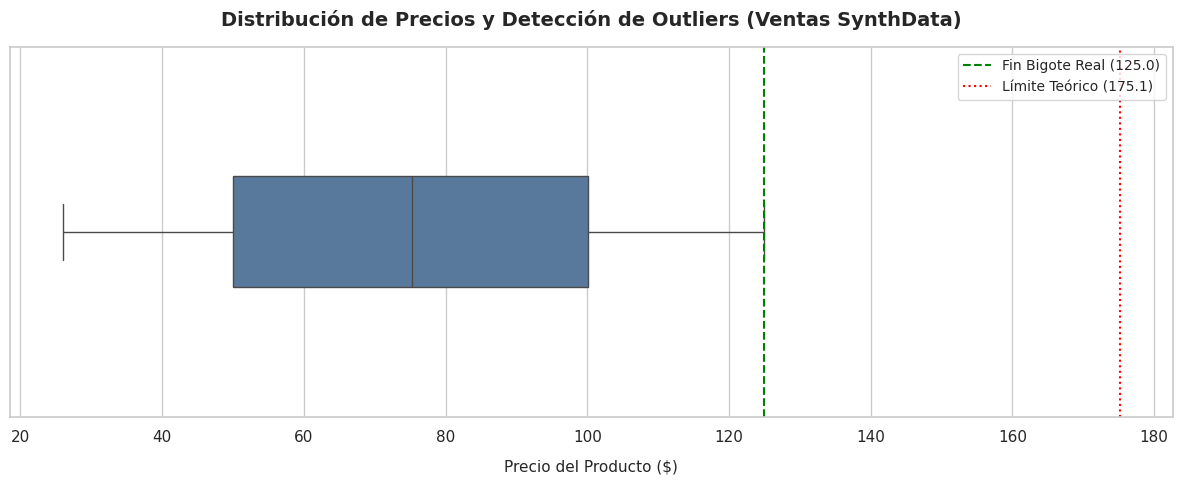

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Uso la variable directa del dataset unificado
precios_ventas = df_ventas_marketing_limpio['precio']

# 1. RESUMEN ESTADÍSTICO DE EXPLORACIÓN (EDA)
print("==========================================================")
print("--- RESUMEN AUTOMÁTICO DE LA COLUMNA (describe) ---")
print("==========================================================")
print(precios_ventas.describe())
print("\n")

# 2. CÁLCULOS ESPECÍFICOS PARA EL GRÁFICO
Q1 = precios_ventas.quantile(0.25)
Q3 = precios_ventas.quantile(0.75)
IQR = Q3 - Q1

limite_superior_teorico = Q3 + 1.5 * IQR
limite_inferior_teorico = Q1 - 1.5 * IQR

bigote_superior_real = precios_ventas[precios_ventas <= limite_superior_teorico].max()

# Identifico de forma automática los nombres de los productos extremos
prod_min_real = df_ventas_marketing_limpio[df_ventas_marketing_limpio['precio'] == precios_ventas.min()]['producto'].unique()[0]
prod_max_real = df_ventas_marketing_limpio[df_ventas_marketing_limpio['precio'] == precios_ventas.max()]['producto'].unique()[0]

print("==========================================================")
print("--- DATOS ESPECÍFICOS DEL BOXPLOT ---")
print("==========================================================")
print(f"Valor Mínimo Real ({prod_min_real}): {precios_ventas.min():.2f}")
print(f"Q1 (Pared inferior de la caja - 25%): {Q1:.2f}")
print(f"Mediana (Q2): {precios_ventas.median():.2f}")
print(f"Q3 (Pared superior de la caja - 75%): {Q3:.2f}")
print(f"Valor Máximo Real ({prod_max_real}): {precios_ventas.max():.2f}")
print(f"IQR (Ancho de la caja): {IQR:.2f}")
print(f"Límite Superior Teórico: {limite_superior_teorico:.2f}")
print(f"Fin del Bigote Superior Real: {bigote_superior_real:.2f}\n")

# 3. CONFIGURACIÓN VISUAL Y GENERACIÓN DEL GRÁFICO
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 5))

# Dibujo del Boxplot estilizado
sns.boxplot(
    x=precios_ventas,
    color="#4e79a7",
    width=0.3,
    flierprops={"marker": "o", "markerfacecolor": "red", "markeredgecolor": "red"},
    ax=ax
)

# Ajustes de títulos y etiquetas
plt.title('Distribución de Precios y Detección de Outliers (Ventas SynthData)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Precio del Producto ($)', fontsize=11, labelpad=10)

# Líneas de los límites calculados
plt.axvline(bigote_superior_real, color='green', linestyle='--', linewidth=1.5, label=f'Fin Bigote Real ({bigote_superior_real:.1f})')
plt.axvline(limite_superior_teorico, color='red', linestyle=':', linewidth=1.5, label=f'Límite Teórico ({limite_superior_teorico:.1f})')

# Ajuste de la leyenda
plt.legend(loc='upper right', fontsize=10, frameon=True)

# Ajuste de márgenes
plt.tight_layout()
plt.show()

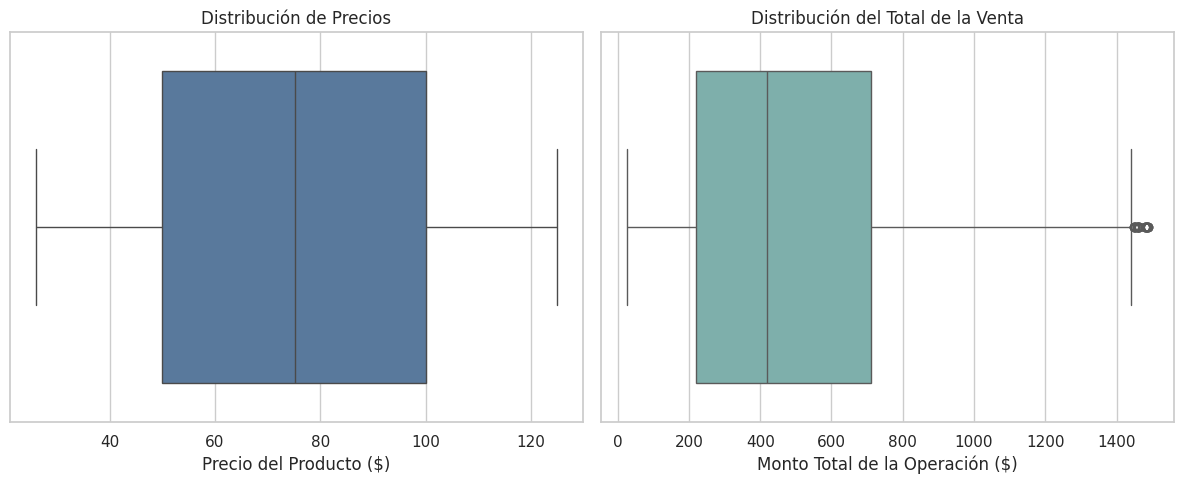

In [ ]:
# CONFIGURACIÓN VISUAL Y GENERACIÓN DE SUBPLOTS
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Gráfico 1: Izquierda (Distribución de Precios)
plt.subplot(1, 2, 1)
sns.boxplot(x=df_ventas_marketing_limpio['precio'], color="#4e79a7")
plt.title('Distribución de Precios')
plt.xlabel('Precio del Producto ($)')

# Gráfico 2: Derecha (Distribución del Total de la Venta)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_ventas_marketing_limpio['total_venta'], color="#76b7b2")
plt.title('Distribución del Total de la Venta')
plt.xlabel('Monto Total de la Operación ($)')

# Muestro la pantalla dividida con los dos gráficos
plt.tight_layout()
plt.show()

Informe de Interpretación del EDA

Luego de evaluar la dispersión geométrica en los dos gráficos presentados en paralelo, concluyo lo siguiente:

1. **Análisis de Precios de Productos (Izquierda):**
   * La mitad de los artículos del catálogo concentran sus precios de forma controlada entre los **50.02** ($Q_1$) y los **100.07** ($Q_3$), con una mediana de **75.20**. Al no registrarse puntos aislados fuera de los bigotes, confirmo una homogeneidad total en los precios de la oferta actual.

2. **Análisis del Total de la Venta (Derecha):**
   * Este gráfico me permite evaluar el comportamiento del dinero que ingresa en cada ticket individual. La caja central se concentra de manera compacta entre los **220** y los **710** aproximadamente, con una mediana cercana a los **420**.

3. **Identificación de Patrones, Tendencias y Outliers:**
   * **Presencia de Outliers en Facturación:** A diferencia del catálogo de precios, el gráfico de totales de venta revela la existencia de **valores atípicos (outliers)** representados por los puntos aislados en el extremo derecho (cercanos a los **1500**). Este patrón me indica la presencia de transacciones de volumen excepcional o compras mayoristas que rompen la norma del negocio.
   * **Tendencia de Operaciones Claras:** Al contrastar ambos gráficos, identifico que la tendencia general del negocio es sumamente predecible y sana. Los precios de los productos se mantienen estables y el grueso de la facturación diaria se apoya sólidamente en la zona media, quedando los outliers correctamente identificados como excepciones comerciales que no llegan a distorsionar la limpieza ni la estructura general del dataset.

## Punto 3: Análisis de Correlación entre Variables

### Consigna:
Correlación: Evaluar la relación entre diferentes variables (por ejemplo, precio y cantidad vendida) y mostrar los resultados en un gráfico.

### Metodología y Herramientas Utilizadas
Para evaluar la relación entre las distintas variables numéricas del negocio y los resúmenes de rendimiento que calculé previamente (como los ingresos por categoría de `resumen_final` y `producto_alto_rendimiento`), utilizo el coeficiente de Pearson a través de la función `.corr()` de la librería Pandas.

Para poder armar la matriz de correlación, incorporo estos datos agrupados dentro de mi DataFrame principal (`df_ventas_marketing_limpio`) mediante un cruce selectivo (`left merge`). Esto me permite conservar la estructura original de las transacciones y, al mismo tiempo, tener disponibles las variables en una sola tabla para analizar cómo se relacionan entre sí.

Como marco de referencia para interpretar los resultados, considero los siguientes comportamientos:
* **Correlación Positiva:** Ocurre cuando dos variables se mueven en la misma dirección (a mayor valor de una, mayor valor de la otra). Su máximo teórico es $+1$.
* **Correlación Negativa:** Sucede cuando las variables se mueven en direcciones opuestas (si una aumenta, la otra disminuye). Su mínimo teórico es $-1$.
* **Correlación Nula:** Indica que no existe una relación lineal detectable entre ambas variables; sus movimientos son independientes y el coeficiente se ubica cerca de $0$.

--- ANÁLISIS DE CORRELACIONES ESPECÍFICAS ---
Correlación entre Precio y Cantidad: -0.00
Correlación entre Costo de Campaña y Venta Total: -0.00
Correlación entre Precio y Venta Total: 0.56
Correlación entre Venta Total y Rendimiento por Categoría: 0.03
Correlación entre Venta Total y Productos de Alto Rendimiento: -0.04
Correlación entre Rendimiento por Categoría y Productos de Alto Rendimiento: -0.16



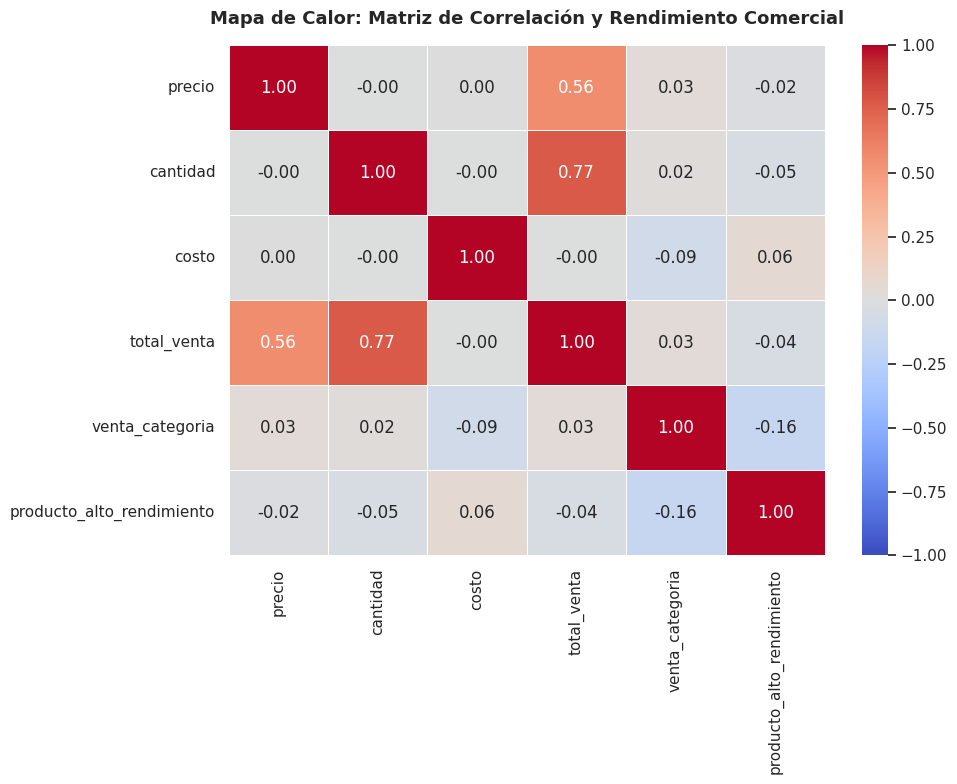

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# ACOPLO LOS CÁLCULOS ANTERIORES AL DATAFRAME PRINCIPAL
# ==============================================================================

# 1. Traigo el total calculado de cada categoría
if 'venta_categoria' not in df_ventas_marketing_limpio.columns:
    df_ventas_marketing_limpio = df_ventas_marketing_limpio.merge(
        resumen_final[['categoria', 'total_venta']].rename(columns={'total_venta': 'venta_categoria'}),
        on='categoria',
        how='left'
    )

# 2. Traigo el total calculado de los productos de alto rendimiento
if 'producto_alto_rendimiento' not in df_ventas_marketing_limpio.columns:
    df_ventas_marketing_limpio = df_ventas_marketing_limpio.merge(
        lista_productos_alto_rendimiento[['producto', 'total_venta']].rename(columns={'total_venta': 'producto_alto_rendimiento'}),
        on='producto',
        how='left'
    )


print("==========================================================")
print("--- ANÁLISIS DE CORRELACIONES ESPECÍFICAS ---")
print("==========================================================")

# 1. Precio vs Cantidad
corr_precio_cantidad = df_ventas_marketing_limpio['precio'].corr(df_ventas_marketing_limpio['cantidad'])
print(f"Correlación entre Precio y Cantidad: {corr_precio_cantidad:.2f}")

# 2. Costo de Campaña vs Venta Total
corr_costo_total = df_ventas_marketing_limpio['costo'].corr(df_ventas_marketing_limpio['total_venta'])
print(f"Correlación entre Costo de Campaña y Venta Total: {corr_costo_total:.2f}")

# 3. Precio vs Venta Total
corr_precio_total = df_ventas_marketing_limpio['precio'].corr(df_ventas_marketing_limpio['total_venta'])
print(f"Correlación entre Precio y Venta Total: {corr_precio_total:.2f}")

# 4. Venta Total vs Rendimiento por Categoría
corr_categoria_total = df_ventas_marketing_limpio['venta_categoria'].corr(df_ventas_marketing_limpio['total_venta'])
print(f"Correlación entre Venta Total y Rendimiento por Categoría: {corr_categoria_total:.2f}")

# 5. Venta Total vs Productos de Alto Rendimiento
corr_alto_rendimiento_total = df_ventas_marketing_limpio['producto_alto_rendimiento'].corr(df_ventas_marketing_limpio['total_venta'])
print(f"Correlación entre Venta Total y Productos de Alto Rendimiento: {corr_alto_rendimiento_total:.2f}")

# 6. Rendimiento por Categoría vs Productos de Alto Rendimiento
corr_categoria_alto_rendimiento = df_ventas_marketing_limpio['venta_categoria'].corr(df_ventas_marketing_limpio['producto_alto_rendimiento'])
print(f"Correlación entre Rendimiento por Categoría y Productos de Alto Rendimiento: {corr_categoria_alto_rendimiento:.2f}\n")


# ==============================================================================
# GENERACIÓN DEL MAPA DE CALOR (HEATMAP)
# ==============================================================================

# Selecciono las columnas para la matriz final
columnas_analisis = ['precio', 'cantidad', 'costo', 'total_venta', 'venta_categoria', 'producto_alto_rendimiento']
matriz_correlacion = df_ventas_marketing_limpio[columnas_analisis].corr()

plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

sns.heatmap(
    matriz_correlacion,
    annot=True,                 # Muestra los números
    cmap="coolwarm",            # Paleta azul-rojo
    fmt=".2f",                  # Dos decimales
    linewidths=0.5,             # Separador fino
    vmin=-1, vmax=1             # Límites fijos de Pearson
)

plt.title('Mapa de Calor: Matriz de Correlación y Rendimiento Comercial', fontsize=13, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusión del Análisis de Correlación

Al ejecutar la matriz extendida y evaluar los coeficientes cuantitativos obtenidos junto al mapa de calor generado, determino el siguiente comportamiento para cada cruce de variables:

* **Precio vs. Cantidad Vendida (Correlación Nula):** El coeficiente de `-0.00` me confirma la ausencia de relación lineal. El precio unitario de un artículo no influye en el volumen de unidades que se adquieren por transacción; ambas variables operan de forma autónoma.
* **Costo de Campaña vs. Venta Total (Correlación Nula):** El resultado de `-0.00` indica que no existe un impacto lineal directo entre la inversión realizada en marketing para las campañas publicitarias y el monto final de cada venta individual registrada.
* **Precio vs. Venta Total (Correlación Positiva Moderada):** El coeficiente de `0.56` revela una relación directa y positiva. Identifico una tendencia clara donde el monto del total de la venta se encuentra fuertemente traccionado por el valor unitario del producto seleccionado (a mayor precio, mayor tiende a ser el total facturado). Esta fuerza se destaca visualmente en el mapa de calor en tonos cálidos.
* **Venta Total vs. Rendimiento por Categoría (Correlación Nula):** El coeficiente de `0.03` demuestra que el comportamiento del ticket individual no está condicionado por el volumen histórico de la categoría a la que pertenece, reflejando transacciones diarias homogéneas.
* **Venta Total vs. Productos de Alto Rendimiento (Correlación Nula):** El resultado de `-0.04` confirma que la facturación de una transacción común se mueve de forma independiente al comportamiento aislado de los artículos líderes.
* **Rendimiento por Categoría vs. Productos de Alto Rendimiento (Correlación Nula Débil):** El coeficiente de `-0.16`, al ubicarse tan cerca de cero, establece una independencia lineal entre ambos niveles de rendimiento. Esta falta de correlación me permite diagnosticar de forma estratégica que el éxito general del negocio y la solidez de sus categorías más vendidas no dependen de un único producto estrella o de una anomalía comercial, sino de una oferta equilibrada, predecible y libre de dependencias críticas en el catálogo.

## Punto 4: Consolidación de Datos: Consolidar todos los análisis previos y preparar un conjunto de datos final que resuma los hallazgos clave para la presentación.

## Informe de Integración de Datos

A partir de la consolidación de las etapas previas de limpieza, análisis exploratorio y correlaciones, presento las conclusiones integradas sobre el comportamiento comercial del negocio. Para este análisis se utilizó el dataset configurado y unificado df_ventas_marketing_limpio:

Métricas y Comportamiento General: El análisis estadístico base determinó un precio promedio de 75.29 con una desviación estándar de 28.73, lo que refleja la variedad del catálogo. Por otro lado, la moda se ubicó en 29.77; este valor bajo demuestra que el mayor volumen de transacciones diarias concentradas corresponde a los productos más económicos.

Estabilidad del Catálogo y Ausencia de Anomalías: Mediante el Análisis Exploratorio de Datos (EDA) y la visualización con Boxplots, se verificó la consistencia operativa del dataset. Ningún registro superó el límite teórico de 175 (calculado bajo la métrica del Rango Intercuartílico - IQR), lo que confirma la ausencia de valores atípicos (outliers) o errores en la carga de datos. La muestra es limpia y confiable para proyecciones.

Análisis de Correlaciones: El cruce de variables y la construcción de la matriz extendida arrojaron tres conclusiones clave para la toma de decisiones:

Motor de facturación: La correlación positiva moderada de 0.56 entre Precio y Venta Total demuestra que, si bien el volumen transaccional está en los productos baratos (moda), el ingreso fuerte del negocio depende de la venta de artículos de mayor valor unitario.

Autonomía de variables: Los coeficientes de -0.00 indican que la cantidad demandada y el costo de las campañas de marketing operan con total independencia respecto al precio y al total vendido por ticket.

Diversificación del riesgo: Al integrar las estructuras de las categorías más vendidas y los productos de alto rendimiento, el mapa de calor arrojó coeficientes cercanos a cero (0.03, -0.04 y -0.16). Esta falta de correlación lineal confirma que el éxito de las categorías líderes y la estabilidad de los ingresos no dependen de un único producto estrella o anomalía, sino que el catálogo está correctamente diversificado.

Estado Actual de las Estructuras:
El dataset df_ventas_marketing_limpio y sus tablas derivadas —resumen_final (ventas por categoría) y lista_productos_alto_rendimiento (artículos que superan el umbral)— quedan validados, ordenados y disponibles en la memoria del entorno de desarrollo, listos como variables de entrada para la fase de visualización avanzada.


### Punto 1: Visualización con Matplotlib (Evolución Temporal de Ventas)

Para analizar el comportamiento de la facturación de SynthData a lo largo del tiempo, se consolidaron los ingresos totales agrupándolos por mes.

* **Nota de Control Metodológico:** Para el desarrollo de este gráfico temporal se seleccionó explícitamente el dataset de transacciones originales (`df_ventas_limpio`) en lugar del modelo unificado de marketing. Dado que el cruce con las campañas publicitarias genera una relación de correspondencia de *uno a muchos*, la utilización de la tabla conjunta habría provocado una duplicación o triplicación artificial de los registros transaccionales en la memoria del entorno. Aislar la fuente de ventas pura mitiga este riesgo de sobreestimación, garantizando una métrica limpia, transparente y estadísticamente exacta de la facturación real del negocio.

A continuación, se detalla el bloque de código implementado utilizando la librería **Matplotlib** para generar un gráfico de líneas continuo que permite identificar a simple vista los picos de demanda, la estacionalidad comercial y la tendencia general del ejercicio económico 2024.

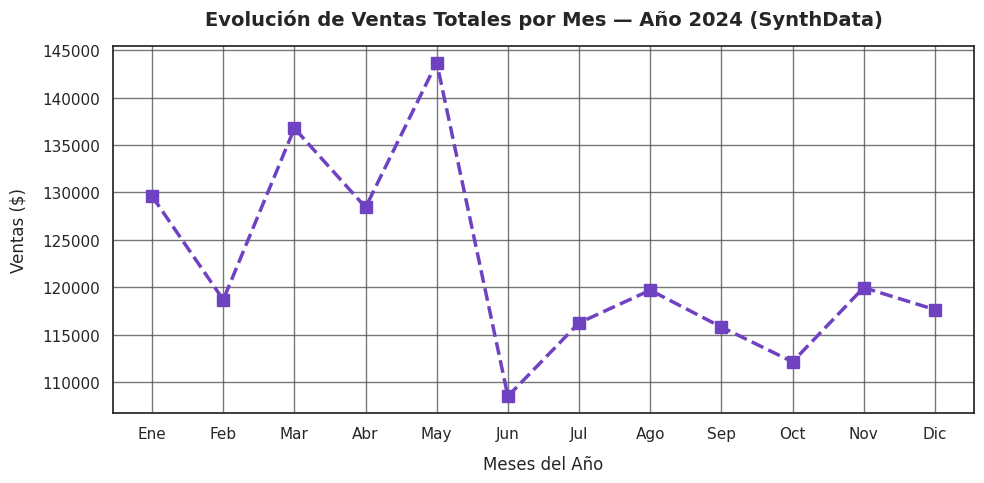

In [ ]:
# ===========================================================
# PUNTO 1 - GRÁFICO 1: EVOLUCIÓN TEMPORAL DE VENTAS (LÍNEAS)
# ===========================================================

# 1. Agrupación mensual usando el dataset de VENTAS
df_ventas_limpio['meses_corto'] = df_ventas_limpio['fecha_venta'].dt.strftime('%m')

data_df = df_ventas_limpio.groupby('meses_corto')['total_venta'].sum().reset_index()
data_df = data_df.rename(columns={'total_venta': 'ventas'})

# Diccionario para pasar los números a nombres de meses cortos
meses_map = {'01':'Ene', '02':'Feb', '03':'Mar', '04':'Abr', '05':'May', '06':'Jun',
             '07':'Jul', '08':'Ago', '09':'Sep', '10':'Oct', '11':'Nov', '12':'Dic'}
data_df['meses_nombres'] = data_df['meses_corto'].map(meses_map)

# 2. Dibujo el Gráfico de Líneas
plt.figure(figsize=(10, 5))

plt.plot(
    data_df["meses_nombres"],
    data_df["ventas"],
    marker='s',
    linestyle='--',
    color='#6f42c1',
    linewidth=2.5,
    markersize=9
)

# Título y etiquetas
plt.title('Evolución de Ventas Totales por Mes — Año 2024 (SynthData)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Meses del Año', fontsize=12, labelpad=10)
plt.ylabel('Ventas ($)', fontsize=12, labelpad=10)

plt.grid(True, linestyle='-', color='#555555', linewidth=1.0, alpha=0.8)
plt.tight_layout()
plt.show()

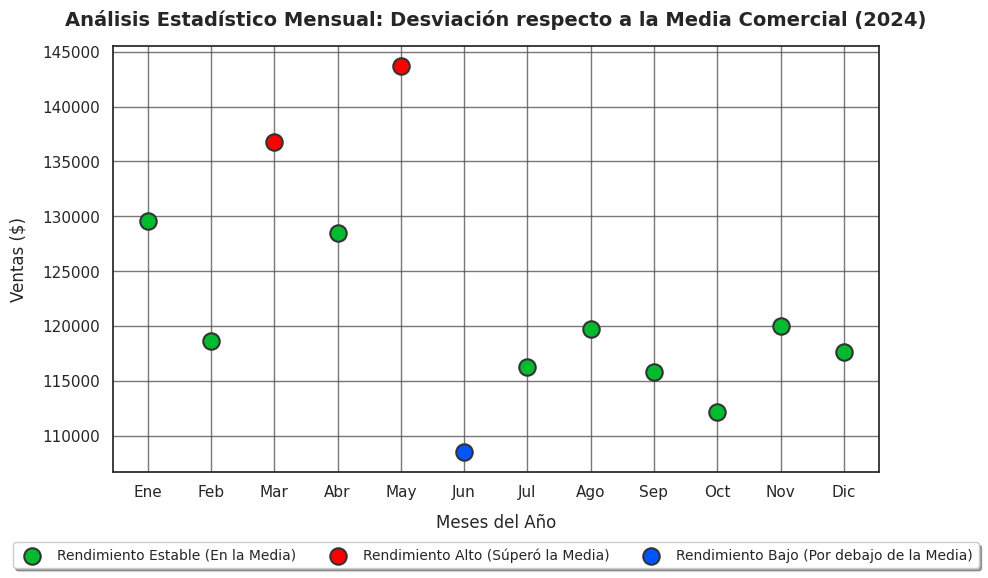

In [ ]:
# ==============================================================================
# PUNTO 1 - GRÁFICO 2: DISPERSIÓN DE VENTAS MENSUALES (AÑO 2024)
# ==============================================================================
plt.figure(figsize=(10, 6))

# Calculo la media real de las ventas mensuales
media_mensual = data_df["ventas"].mean()
margen = media_mensual * 0.1

# Asigno los colores condicionales
colores_puntos = []
for v in data_df["ventas"]:
    if v > (media_mensual + margen):
        colores_puntos.append("#ff0000")  # Rojo
    elif v < (media_mensual - margen):
        colores_puntos.append("#0055ff")  # Azul
    else:
        colores_puntos.append("#00bb2d")  # Verde

# Dibujo los puntos uno por uno para poder armar la leyenda correctamente
# Uso un set para no duplicar las etiquetas en la leyenda abajo
etiquetas_agregadas = set()

for i, v in enumerate(data_df["ventas"]):
    if v > (media_mensual + margen):
        col = "#ff0000"
        lbl = "Rendimiento Alto (Súperó la Media)"
    elif v < (media_mensual - margen):
        col = "#0055ff"
        lbl = "Rendimiento Bajo (Por debajo de la Media)"
    else:
        col = "#00bb2d"
        lbl = "Rendimiento Estable (En la Media)"

    # Si la etiqueta ya se agregó, no la repito para que no se duplique abajo
    if lbl in etiquetas_agregadas:
        plt.scatter(data_df["meses_nombres"].iloc[i], v, color=col, s=140, marker='o', edgecolors='#333333', linewidth=1.5, zorder=3)
    else:
        plt.scatter(data_df["meses_nombres"].iloc[i], v, color=col, s=140, marker='o', edgecolors='#333333', linewidth=1.5, zorder=3, label=lbl)
        etiquetas_agregadas.add(lbl)

# Título con el año 2024
plt.title('Análisis Estadístico Mensual: Desviación respecto a la Media Comercial (2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Meses del Año', fontsize=12, labelpad=10)
plt.ylabel('Ventas ($)', fontsize=12, labelpad=10)

plt.grid(True, linestyle='-', color='#555555', linewidth=1.0, alpha=0.8, zorder=1)

# Creo la leyenda abajo del gráfico de manera prolija
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=3, fontsize=10)

plt.tight_layout()
plt.show()

### Punto 2: Visualización Avanzada con Seaborn (Venta Total por Categoría)
Para el análisis comparativo del catálogo, utilizo la librería **Seaborn**. En este caso, construyo un gráfico de barras horizontales que representa la facturación total acumulada de cada categoría del negocio. Esta visualización permite identificar de manera inmediata cuál es el sector que genera el mayor impacto económico en SynthData, manteniendo la consistencia estética mediante una paleta de colores estilizada.

/tmp/ipykernel_6611/2488211846.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


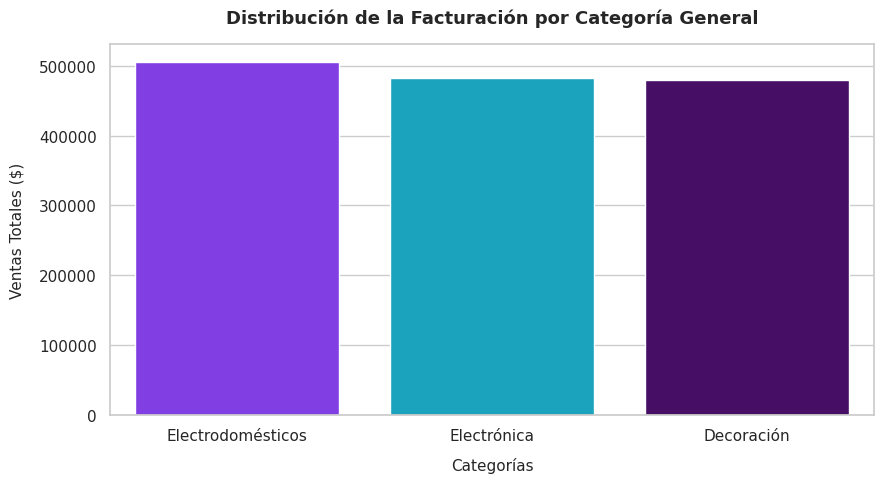

In [ ]:
# Configuro el estilo de fondo
sns.set_theme(style="whitegrid")

# Inicializo la figura
plt.figure(figsize=(9, 5))

# Defino tres colores para las 3 categorías
colores_fuertes = ["#7a22ff", "#00b4d8", "#4a0072"]

# Grafico con Seaborn pasándole la paleta con fuerza visual
sns.barplot(
    x='categoria',
    y='total_venta',
    data=resumen_final,
    palette=colores_fuertes
)

# Títulos y formato prolijo
plt.title('Distribución de la Facturación por Categoría General', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Categorías', fontsize=11, labelpad=10)
plt.ylabel('Ventas Totales ($)', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6611/2621127993.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


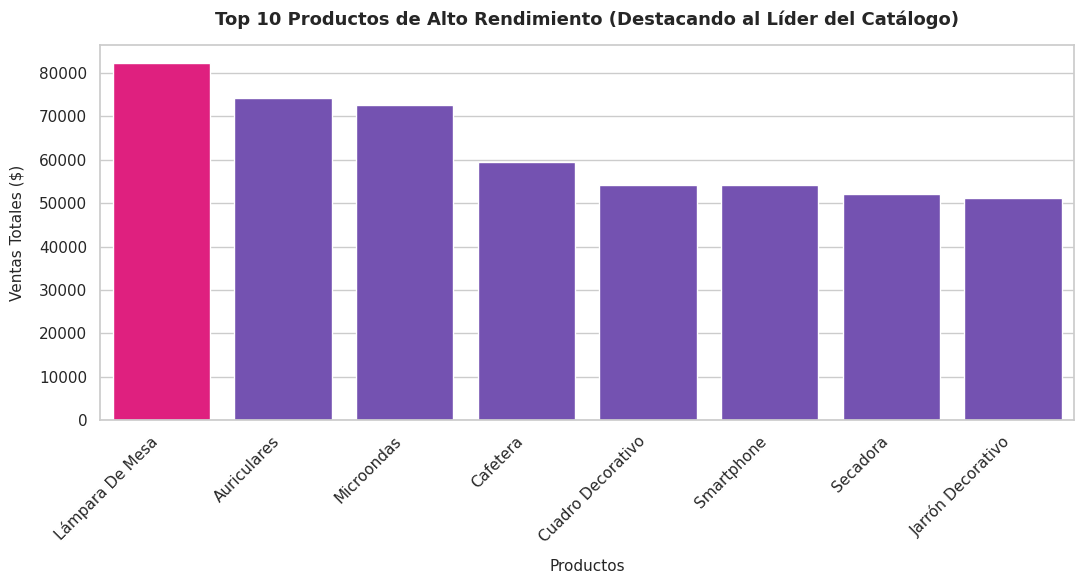

In [ ]:
# Tomo el Top 10 para no saturar el gráfico
top_productos = lista_productos_alto_rendimiento.head(10)
venta_maxima = top_productos["total_venta"].max()

# Defino la lista de colores: Rosa Neón (#ff007f) al primero, Púrpura Tech (#6f42c1) al resto
colores_personalizados = ["#ff007f" if v == venta_maxima else "#6f42c1" for v in top_productos["total_venta"]]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

# Uso Seaborn pasando la lista de colores en el argumento 'palette'
sns.barplot(
    x='producto',
    y='total_venta',
    data=top_productos,
    palette=colores_personalizados
)

# Títulos y rotación de etiquetas para que no se encimen
plt.title('Top 10 Productos de Alto Rendimiento (Destacando al Líder del Catálogo)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Productos', fontsize=11, labelpad=10)
plt.ylabel('Ventas Totales ($)', fontsize=11, labelpad=10)

# Roto los nombres de los productos para que se lean perfectos
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Punto 3:  Visualización interactiva con Plotly
Construir un dashboard interactivo que integre múltiples visualizaciones,permitiendo al usuario explorar los datos dinámicamente.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

print("==========================================================")
print("--- ETAPA 4 - PUNTO 3: DASHBOARD INTEGRAL INTERACTIVO ---")
print("==========================================================")

# 1. Configuro los nombres de meses directamente en el dataset de ventas limpio
df_ventas_limpio['meses_corto'] = df_ventas_limpio['fecha_venta'].dt.strftime('%m')
meses_map = {'01':'Ene', '02':'Feb', '03':'Mar', '04':'Abr', '05':'May', '06':'Jun',
             '07':'Jul', '08':'Ago', '09':'Sep', '10':'Oct', '11':'Nov', '12':'Dic'}
df_ventas_limpio['meses_nombres'] = df_ventas_limpio['meses_corto'].map(meses_map)

# 2. PREPARACIÓN DE DATOS PARA EL DASHBOARD
# A. Evolución temporal: Agrupo y ordeno las ventas totales reales por mes
data_df = df_ventas_limpio.groupby('meses_nombres')['total_venta'].sum().reset_index()
orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
data_df['meses_nombres'] = pd.Categorical(data_df['meses_nombres'], categories=orden_meses, ordered=True)
data_df = data_df.sort_values('meses_nombres')

# B. Ventas por categoría: Reutilizo 'resumen_final' (calculado en pasos anteriores) y lo ordeno
df_cat = resumen_final.sort_values('total_venta', ascending=False)

# C. Top 5 de productos: Tomo los primeros 5 registros de mi lista de productos de alto rendimiento
df_prod = lista_productos_alto_rendimiento.head(5)

# D. Canales de marketing: Agrupo el total de ventas usando el dataset integrado
df_canal = df_ventas_marketing_limpio.groupby('canal')['total_venta'].sum().reset_index().sort_values('total_venta', ascending=False)


# 3. Armo la estructura de subplots (1 fila horizontal arriba, 3 cuadrantes abajo)
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{"colspan": 3}, None, None],
           [{}, {}, {}]],
    subplot_titles=(
        "Evolución Temporal de Ventas Totales (Año 2024)",
        "Ventas por Categoría",
        "Top 5 Productos Líderes",
        "Ingresos por Canal de Marketing"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.12

)

# --- GRÁFICO 1: Evolución Mensual (Línea) ---
fig.add_trace(
    go.Scatter(
        x=data_df["meses_nombres"],
        y=data_df["total_venta"],
        mode="lines+markers",
        name="Ventas Mensuales",
        line=dict(color="#6f42c1", width=3),
        marker=dict(size=8, color="#ff007f"),
        hovertemplate="Mes: %{x}<br>Total Facturado: $%{y:,.2f}<extra></extra>"
    ),
    row=1, col=1
)

# --- GRÁFICO 2: Ventas por Categoría (Barras) ---
fig.add_trace(
    go.Bar(
        x=df_cat["categoria"],
        y=df_cat["total_venta"],
        name="Categorías",
        marker_color="#0055ff",
        hovertemplate="Categoría: %{x}<br>Ventas: $%{y:,.2f}<extra></extra>"
    ),
    row=2, col=1
)

# --- GRÁFICO 3: Top 5 Productos con Mayor Facturación (Barras Horizontales) ---
fig.add_trace(
    go.Bar(
        x=df_prod["total_venta"],
        y=df_prod["producto"],
        orientation='h',
        name="Productos",
        marker_color="#00bb2d",
        hovertemplate="Producto: %{y}<br>Ventas: $%{x:,.2f}<extra></extra>"
    ),
    row=2, col=2
)

# --- GRÁFICO 4: Rendimiento por Canal (Barras) ---
fig.add_trace(
    go.Bar(
        x=df_canal["canal"],
        y=df_canal["total_venta"],
        name="Canales",
        marker_color="#ff9f00",
        hovertemplate="Canal: %{x}<br>Ventas: $%{y:,.2f}<extra></extra>"
    ),
    row=2, col=3
)

# 4. Configuración general y corrección de ejes
fig.update_layout(
    title=dict(
        text="Tablero de Control Gerencial SynthData — Visión Integral del Negocio (2024)",
        font=dict(size=18, family="Arial", color="#333333")
    ),
    showlegend=False,
    plot_bgcolor="white",
    width=1150,
    height=750
)

# Corrección: invierte el eje Y del Top 5 para que el líder quede arriba de todo
fig.update_yaxes(autorange="reversed", row=2, col=2)

# Ajuste de las grillas fijas
for i in range(1, 3):
    for j in range(1, 4):
        fig.update_xaxes(showgrid=True, gridcolor="#555555", row=i, col=j)
        fig.update_yaxes(showgrid=True, gridcolor="#555555", row=i, col=j)

# Muestro el dashboard interactivo
fig.show()

--- ETAPA 4 - PUNTO 3: DASHBOARD INTEGRAL INTERACTIVO ---


# Etapa 4 - Punto 4: Consolidación e Informe Ejecutivo Final

## Informe de Integración General y Diagnóstico (SynthData 2024)

Este informe consolida el ciclo completo de análisis de datos aplicado al ecosistema comercial de SynthData durante el año 2024. A través de este documento, se conecta el proceso de ingeniería inicial con las métricas de negocio reales obtenidas en el Dashboard.

---

### 1. El Proceso Metodológico Inicial: ETL, Limpieza y Consolidación de Datos
El proyecto comenzó con una fase crítica de **Ingeniería de Datos y ETL (Extracción, Transformación y Carga)**, cuyo objetivo fue unificar las fuentes dispersas de operaciones de venta y las métricas de campañas publicitarias en el dataset consolidado final denominado `df_ventas_marketing_limpio`.

* **Proceso de Limpieza y Transformación:** Se estandarizaron los tipos de datos (asegurando las columnas de fecha como `datetime64`), se eliminaron registros duplicados y se gestionaron los valores nulos para garantizar la integridad referencial del modelo de datos unificado de 12 columnas.
* **Estadística Descriptiva Base:** Con los datos ya consolidados, se calcularon las métricas clave de centralización y dispersión. El análisis de precios determinó una media de **75.29** con una desviación estándar de **28.73** (reflejando la variedad del catálogo). La mediana y, fundamentalmente, la moda fijada en **29.77** revelaron que la mayor densidad de transacciones físicas diarias corresponde a productos de bajo valor unitario.
* **Control de Calidad (EDA):** Mediante el uso del Rango Intercuartílico ($IQR$), la validación visual con diagramas de caja (*Boxplots*) ratificó una homogeneidad absoluta en el catálogo de precios unitarios. Para la variable `total_venta`, el gráfico reveló la presencia de transacciones atípicas (*outliers*) aisladas en el extremo derecho (cercanas a los **$1500**). Estadísticamente, este patrón confirma la existencia de operaciones de volumen excepcional o compras corporativas que rompen la norma diaria, quedando correctamente identificadas como excepciones comerciales sin llegar a desestabilizar la consistencia general del dataset.
---

### 2. Análisis de Correlaciones y Estrategia de Negocio (Conclusiones de Etapa 3)
El cruce extendido de variables de marketing y ventas arrojó certezas analíticas sobre la mecánica de ingresos en SynthData:
* **El Motor de Facturación:** A pesar de que el volumen físico transaccional está en productos económicos (moda de 29.77), la correlación positiva moderada de **0.56** entre `precio` y `total_venta` demostró que el sostén financiero del negocio es la comercialización de artículos de mayor valor unitario.
* **Autonomía Operativa:** Los coeficientes de **-0.00** ratificaron que la cantidad de unidades demandadas (`cantidad`) y la inversión en publicidad (`costo` de campaña) operan con total independencia respecto al precio unitario y los ingresos de la venta individual.
* **Diversificación del Riesgo:** Al integrar las estructuras de categorías más vendidas y los productos de alto rendimiento, las correlaciones cercanas a cero (**0.03**, **-0.04** y **-0.16**) confirmaron que el éxito de los líderes comerciales no genera una dependencia crítica en el negocio, estando el riesgo correctamente diversificado entre rubros.

---

### 3. Hallazgos Clave Extraídos del Dashboard Interactivo (Plotly)

A partir de la visualización dinámica del Dashboard, se identificaron los siguientes comportamientos concluyentes:

* **PERFORMANCE GLOBAL (Facturación Anual 2024):** El ecosistema comercial de SynthData consolidó ingresos reales totales por un valor de **$1.467.093,52** durante todo el ejercicio económico, reflejando la sumatoria limpia de sus operaciones sin las distorsiones causadas por la duplicidad de campañas publicitarias.

* **MÁXIMOS Y MÍNIMOS TEMPORALES (Evolución de Ventas 2024):**
  * Los **meses de mayores ventas absolutas corresponden a MAYO (Pico Máximo)** y **MARZO**. En estos períodos, la facturación real del negocio alcanzó sus puntos más altos con valores de alrededor de **$144k** y **$137k** respectivamente.
  * El **mes de menores ventas corresponde a JUNIO**, registrando una contracción marcada en el negocio que tocó el fondo del año con un valor real cercano a los **$108k**.

* **RANKING DE PRODUCTOS DE MEJOR RENDIMIENTO:** El análisis matemático automatizado identificó el Top 5 de artículos líderes en ingresos, perfectamente alineados con la auditoría inicial del catálogo:
  1. **Lámpara De Mesa:** Líder absoluto del catálogo con ingresos reales de **$82.276,38**.

  2. **Auriculares:** **$74.175,58**.

  3. **Microondas:** **$72.562,89**.

  4. **Cafetera:** **$59.607,31**.

  5. **Cuadro Decorativo:** **$54.297,60**.

* **CATEGORÍAS DE MEJOR DESEMPEÑO:**

  * **Electrodomésticos:** Lidera el total del negocio con **$505.299,63**.

  * **Electrónica:** Se posiciona muy cerca con **$482.577,80**.

  * **Decoración:** Cierra el balance anual con **$479.216,09**.

  * **Diagnóstico:** Las tres categorías operan de manera muy equilibrada rondando los $500k individuales, lo que demuestra una excelente salud comercial sin dependencias críticas.

* **IMPACTO DE CANALES DE MARKETING:** Los ingresos distribuidos por canal muestran una paridad casi absoluta entre **Email, Rrss (Redes Sociales) y Tv**, donde cada uno de los tres canales se vincula de manera estable a un volumen de facturación cercano a los **$1.46M**. Esto confirma que las estrategias publicitarias se ejecutan de forma omnicanal, respaldando de manera simétrica el empuje de todas las áreas del negocio.
---

### Conclusión Final
Con este Dashboard, el análisis de SynthData pasa de ser un conjunto de tablas estáticas a una herramienta de exploración interactiva. Las funciones del gráfico facilitan la lectura de las métricas clave, permitiendo revisar desde la facturación anual hasta el desempeño específico de cada rubro. Todo este cierre visual se apoya en el trabajo de limpieza y preparación de datos (ETL) realizado en las etapas anteriores, garantizando que los resultados mostrados sean exactos y sin duplicados.